# NB-02: エンティティ統計特徴量の構築

**目的**: 騎手・調教師・種牡馬の条件別パフォーマンス統計を、**時系列リーク防止** を守りながら構築し、
NB-01 の master dataset に結合する。

## 参照仕様書
- `docs/decisions/AREA-07-modeling.md` §4 — 特徴量定義
- `docs/decisions/AREA-08-entity-stats.md` — 本 notebook の設計ドキュメント
- `src/pipeline/features/jockey_trainer_stats.py` — 既存騎手/調教師統計
- `src/pipeline/features/stallion_target_encoder.py` — 本 notebook で使用する種牡馬統計モジュール

## 特徴量グループ

| グループ | モジュール | 列プレフィックス | 特徴 |
|---|---|---|---|
| A. 騎手統計 (既存) | `jockey_trainer_stats.py` | `jk_` | 通算/ローリング/条件別 174 列 |
| B. 調教師統計 (既存) | `jockey_trainer_stats.py` | `tr_` | 通算/ローリング/条件別 174 列 |
| C. 騎手 7 日間 (NEW) | `stallion_target_encoder.py` | `jk_last7d_` | 直近 7 日の starts/wins/top3 |
| D. 調教師 7 日間 (NEW) | `stallion_target_encoder.py` | `tr_last7d_` | 直近 7 日の starts/wins/top3 |
| E. 騎手 venue×surface Bayesian (NEW) | `stallion_target_encoder.py` | `jk_venue_sf_` | 競馬場×馬場別勝率 (スパース補正) |
| F. 調教師 venue×surface Bayesian (NEW) | `stallion_target_encoder.py` | `tr_venue_sf_` | 競馬場×馬場別勝率 (スパース補正) |
| G. 種牡馬統計 (NEW) | `stallion_target_encoder.py` | `sire_` | Bayesian 馬場/距離/venue×sf/grade 別 |
| H. 母父統計 (NEW) | `stallion_target_encoder.py` | `dam_sire_` | Bayesian 馬場/距離/venue×sf/grade 別 |

## リーク防止方針
- 各行には「そのレースの直前」までの成績のみを使用
- `cumsum(n) - current_row` パターンで時系列累計を計算
- 同日他レースは「より前の race_id」のみ参照（race_id = YYYYMMDDVVRR なので日付内の順序も保証）
- 種牡馬統計: 直前累計 + Bayesian Shrinkage（スパース対策）

In [1]:
import sys, os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# プロジェクトルートを sys.path に追加
PROJECT_ROOT = Path("/home/jovyan/work/keiba-vpn")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import json

from src.pipeline.features.stallion_target_encoder import (
    build_all_sire_stats,
    build_jt_extended_stats,
)

# ── パス定義 ─────────────────────────────────────────────────────────────────
TABLES_DIR    = PROJECT_ROOT / "data/page_reference/tables"
LOCAL_FEAT    = PROJECT_ROOT / "data/local/features"
MODELING_DIR  = PROJECT_ROOT / "data/local/modeling"
OUTPUT_DIR    = MODELING_DIR / "entity_stats"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALL_YEARS = [str(y) for y in range(2020, 2026)]
SPLITS    = ["train", "valid", "test"]

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ALL_YEARS: {ALL_YEARS}")

PROJECT_ROOT: /home/jovyan/work/keiba-vpn
ALL_YEARS: ['2020', '2021', '2022', '2023', '2024', '2025']


## 1. 生データ読み込み

### 1-1. レース結果（2020–2025）
### 1-2. 出馬表（sire / dam_sire を取得するため）
### 1-3. Master dataset (NB-01 出力) — split ラベル取得用

In [2]:
# ── 1-1. レース結果 ────────────────────────────────────────────────────────
rr_parts = []
for year in ALL_YEARS:
    p = TABLES_DIR / year / "race_result_flat.parquet"
    if p.exists():
        rr_parts.append(pd.read_parquet(p))
    else:
        print(f"  WARN: {p} が見つかりません")

rr_all = pd.concat(rr_parts, ignore_index=True)
rr_all["date"] = pd.to_datetime(rr_all["date"], errors="coerce")

# JRA中央のみ
vc = pd.to_numeric(rr_all["venue_code"], errors="coerce")
rr_all = rr_all[vc.between(1, 10, inclusive="both")].copy()
print(f"レース結果 (JRA中央): {rr_all.shape}")
print(f"  date range: {rr_all['date'].min().date()} ~ {rr_all['date'].max().date()}")
print(f"  surface値: {rr_all['surface'].value_counts().to_dict()}")

# ── 1-2. 出馬表（sire / dam_sire 取得） ────────────────────────────────────
sb_parts = []
for year in ALL_YEARS:
    p = TABLES_DIR / year / "race_shutuba_flat.parquet"
    if p.exists():
        df = pd.read_parquet(p, columns=["race_id", "horse_number", "sire", "dam_sire"])
        sb_parts.append(df)

sb_all = pd.concat(sb_parts, ignore_index=True).drop_duplicates(
    subset=["race_id", "horse_number"]
)
print(f"\n出馬表 (sire/dam_sire): {sb_all.shape}")

# rr_all に sire / dam_sire を付与
rr_all = rr_all.merge(
    sb_all[["race_id", "horse_number", "sire", "dam_sire"]],
    on=["race_id", "horse_number"], how="left",
)
print(f"  sire 取得率: {rr_all['sire'].notna().mean():.1%}")
print(f"  dam_sire 取得率: {rr_all['dam_sire'].notna().mean():.1%}")

# ── 1-3. Master dataset (split ラベル) ────────────────────────────────────
master_path = MODELING_DIR / "master_dataset_full.parquet"
if master_path.exists():
    spine = pd.read_parquet(master_path, columns=["race_id", "horse_number", "split", "surface_cat"])
    print(f"\nMaster dataset: {spine.shape}")
    print(spine["split"].value_counts())
else:
    print("\nWARN: master_dataset_full.parquet が見つかりません。NB-01 を先に実行してください。")
    spine = None

レース結果 (JRA中央): (286060, 39)
  date range: 2020-01-05 ~ 2025-12-28
  surface値: {'ダート': 145450, '芝': 138627, '障': 1983}



出馬表 (sire/dam_sire): (286060, 4)


  sire 取得率: 100.0%
  dam_sire 取得率: 100.0%

Master dataset: (286060, 4)
split
train    200434
test      43154
valid     42472
Name: count, dtype: int64


## 2. 騎手・調教師統計 (グループ A/B: 既存 jt_race_features)

`jt_race_features.parquet` は `python -m src.pipeline.build_jockey_trainer_stats` で生成済み。
174 列（通算・ローリング・条件別）をそのまま使用する。

In [3]:
# ── 既存 jt_race_features を全年ロード ────────────────────────────────────
jt_parts = []
for year in ALL_YEARS:
    p = LOCAL_FEAT / "race_horse_tbl" / year / "jt_race_features.parquet"
    if p.exists():
        jt_parts.append(pd.read_parquet(p))
    else:
        print(f"  WARN: {p} が見つかりません（未生成）")

if jt_parts:
    jt_all = pd.concat(jt_parts, ignore_index=True)
    jt_all = jt_all.drop_duplicates(subset=["race_id", "horse_id"])
    print(f"jt_race_features (全年): {jt_all.shape}")
    # jk_ / tr_ 列名のプレビュー
    jk_cols = [c for c in jt_all.columns if c.startswith("jk_")]
    tr_cols = [c for c in jt_all.columns if c.startswith("tr_")]
    print(f"  騎手列 ({len(jk_cols)}): {jk_cols[:8]} ...")
    print(f"  調教師列 ({len(tr_cols)}): {tr_cols[:8]} ...")
else:
    print("jt_race_features なし。python -m src.pipeline.build_jockey_trainer_stats を実行してください")
    jt_all = pd.DataFrame()

# 主キーの確認
print(f"\n主キー (race_id + horse_id) 重複: {jt_all.duplicated(subset=['race_id','horse_id']).sum()}")

jt_race_features (全年): (283714, 174)
  騎手列 (84): ['jk_at_dist_avg_finish', 'jk_at_dist_starts', 'jk_at_dist_top3', 'jk_at_dist_top3_rate', 'jk_at_dist_win_rate', 'jk_at_dist_wins', 'jk_at_grade_avg_finish', 'jk_at_grade_starts'] ...
  調教師列 (84): ['tr_at_dist_avg_finish', 'tr_at_dist_starts', 'tr_at_dist_top3', 'tr_at_dist_top3_rate', 'tr_at_dist_win_rate', 'tr_at_dist_wins', 'tr_at_grade_avg_finish', 'tr_at_grade_starts'] ...

主キー (race_id + horse_id) 重複: 0


## 3. 騎手・調教師 拡張統計 (グループ C/D/E/F: NEW)

### 追加する統計

| 列 | 説明 | スパース対策 |
|---|---|---|
| `jk_last7d_starts` | 過去 7 日の出走数 | N/A（カウント） |
| `jk_last7d_wins` | 過去 7 日の勝利数 | N/A |
| `jk_last7d_top3` | 過去 7 日の複勝圏内数 | N/A |
| `jk_venue_sf_win_rate_bayes` | 競馬場×馬場別勝率 | Bayesian (C=50, surface 勝率をベースに) |
| `jk_venue_sf_starts` | 競馬場×馬場の累計出走数 | — |
| _(調教師も同様: `tr_*`)_ | | |

### 計算量の注意
7 日間ローリングは O(n²) のループ処理のため、数百万行では数分かかる。
本 notebook では年別にチャンクして処理する。

In [4]:
from src.pipeline.features.stallion_target_encoder import build_jt_extended_stats

# 7 日間ローリングは全年データが必要（7 日前が前年の場合があるため）
# ただし O(n²) を避けるため、行数が多い場合はサンプリングを検討
print(f"rr_all サイズ: {len(rr_all):,} 行")
print("JT 拡張統計を計算中 (数分かかる場合があります)...")

jt_ext = build_jt_extended_stats(rr_all, jra_only=False)  # JRA フィルタは上で済
print(f"\njt_extended_stats: {jt_ext.shape}")
print("列:", list(jt_ext.columns))

# サンプル表示
print("\nサンプル (5行):")
print(jt_ext[jt_ext["jk_last7d_starts"] > 0].head(5).to_string())

rr_all サイズ: 286,060 行
JT 拡張統計を計算中 (数分かかる場合があります)...



jt_extended_stats: (286060, 12)
列: ['race_id', 'horse_number', 'jk_last7d_starts', 'jk_last7d_wins', 'jk_last7d_top3', 'tr_last7d_starts', 'tr_last7d_wins', 'tr_last7d_top3', 'jk_venue_sf_win_rate_bayes', 'jk_venue_sf_starts', 'tr_venue_sf_win_rate_bayes', 'tr_venue_sf_starts']

サンプル (5行):
        race_id  horse_number  jk_last7d_starts  jk_last7d_wins  jk_last7d_top3  tr_last7d_starts  tr_last7d_wins  tr_last7d_top3  jk_venue_sf_win_rate_bayes  jk_venue_sf_starts  tr_venue_sf_win_rate_bayes  tr_venue_sf_starts
0  202001010101             6              15.0             4.0             6.0               6.0             0.0             1.0                    0.072607                 0.0                    0.072607                 0.0
1  202001010101             2              15.0             4.0             8.0               9.0             2.0             2.0                    0.072607                 0.0                    0.072607                 0.0
2  202001010101             3 

## 4. 種牡馬統計 (グループ G/H: NEW)

### Bayesian Shrinkage 式

```
encoded = (C × μ_prior + Σ local) / (C + n)
```

| 粒度 | C | ベース prior |
|---|---|---|
| entity × global | 30 | データ全体の平均 |
| entity × surface_cat | 20 | entity global 推定値 |
| entity × dist_band | 25 | entity global 推定値 |
| entity × venue × surface | 50 | entity × surface 推定値 |
| entity × grade | 30 | entity global 推定値 |

### 生成カラム（sire_ / dam_sire_ の両方）

| カラム | 内容 |
|---|---|
| `*_prior_starts` | 直前累計出走数（多いほど統計が信頼できる） |
| `*_prior_win_rate` | 全体勝率 (Bayesian) |
| `*_prior_top3_rate` | 全体複勝率 (Bayesian) |
| `*_prior_avg_finish_norm` | 平均着順 / 出走頭数（0=1着, 1=最下位, Bayesian） |
| `*_prior_win_rate_surface` | 馬場別勝率 (Bayesian) |
| `*_prior_top3_rate_surface` | 馬場別複勝率 (Bayesian) |
| `*_prior_avg_finish_norm_surface` | 馬場別平均着順正規化 (Bayesian) |
| `*_prior_avg_pass_surface` | 馬場別平均先頭コーナー通過順（走法傾向） |
| `*_prior_win_rate_dist` | 距離帯別勝率 (Bayesian) |
| `*_prior_top3_rate_dist` | 距離帯別複勝率 (Bayesian) |
| `*_prior_win_rate_venue_sf` | 競馬場×馬場別勝率 (高 Bayesian, C=50) |
| `*_prior_top3_rate_venue_sf` | 競馬場×馬場別複勝率 (高 Bayesian) |
| `*_prior_win_rate_grade` | グレード別勝率 (Bayesian) |
| `*_prior_top3_rate_grade` | グレード別複勝率 (Bayesian) |

In [5]:
print("種牡馬統計を計算中...")

# race_shutuba_flat に sire データが存在する場合のみ計算
_sire_available = (
    rr_all["sire"].notna() & (rr_all["sire"].astype(str).str.strip() != "")
).any() if "sire" in rr_all.columns else False

if _sire_available:
    sire_stats = build_all_sire_stats(rr_all, jra_only=False)
    print(f"\nsire_stats: {sire_stats.shape}")
    sire_cols = [c for c in sire_stats.columns if not c.startswith(("race_id","horse_number"))]
    print(f"列数: {len(sire_cols)}")
    print("列サンプル:", sire_cols[:10])
    if "sire_prior_starts" in sire_stats.columns:
        non_zero = (sire_stats["sire_prior_starts"] > 0).mean()
        print(f"\nsire_prior_starts > 0 の割合: {non_zero:.1%}")
else:
    print("WARN: race_shutuba_flat に sire データが存在しないため、種牡馬統計はスキップします。")
    sire_stats = pd.DataFrame(columns=["race_id", "horse_number"])


種牡馬統計を計算中...
WARN: race_shutuba_flat に sire データが存在しないため、種牡馬統計はスキップします。


## 5. 全エンティティ統計を結合・保存

### 結合キー
- `jt_race_features`: `race_id` + `horse_id`（horse_id は shutuba 経由で取得）
- `jt_extended_stats`: `race_id` + `horse_number`
- `sire_stats`: `race_id` + `horse_number`

### 出力
```
data/local/modeling/entity_stats/
├── entity_stats_full.parquet    # 全期間（推論スナップショット計算用）
├── entity_stats_train.parquet
├── entity_stats_valid.parquet
└── entity_stats_test.parquet
```

In [6]:
# ── 結合用ベーステーブル ───────────────────────────────────────────────────
# horse_number ↔ horse_id の橋渡し
hn_to_hid = (
    rr_all[["race_id", "horse_number", "horse_id"]]
    .drop_duplicates(subset=["race_id", "horse_number"])
    .copy()
)

# ── A/B: 既存 jt_race_features (horse_id キー) ────────────────────────────
entity_base = hn_to_hid.copy()

if not jt_all.empty:
    entity_base = entity_base.merge(
        jt_all.drop(columns=[c for c in jt_all.columns
                              if c in ("jt_result_date","jt_race_datetime",
                                       "jt_row_jockey_id","jt_row_trainer_id")],
                    errors="ignore"),
        on=["race_id", "horse_id"],
        how="left",
    )
    print(f"jt_race_features merge 後: {entity_base.shape}")

# ── C/D/E/F: 拡張統計 (horse_number キー) ─────────────────────────────────
if not jt_ext.empty:
    entity_base = entity_base.merge(
        jt_ext, on=["race_id", "horse_number"], how="left",
    )
    print(f"jt_extended merge 後: {entity_base.shape}")

# ── G/H: 種牡馬統計 (horse_number キー) ──────────────────────────────────
if not sire_stats.empty:
    entity_base = entity_base.merge(
        sire_stats, on=["race_id", "horse_number"], how="left",
    )
    print(f"sire_stats merge 後: {entity_base.shape}")

# ── split ラベル付与 ──────────────────────────────────────────────────────
if spine is not None:
    entity_base = entity_base.merge(
        spine[["race_id", "horse_number", "split"]],
        on=["race_id", "horse_number"], how="left",
    )
else:
    entity_base["split"] = "unknown"

print(f"\n最終 entity_base: {entity_base.shape}")
print("split分布:")
print(entity_base["split"].value_counts())

jt_race_features merge 後: (286060, 171)
jt_extended merge 後: (286060, 181)



最終 entity_base: (286060, 182)
split分布:
split
train    200434
test      43154
valid     42472
Name: count, dtype: int64


In [7]:
# ── 保存 ──────────────────────────────────────────────────────────────────
entity_cols = [c for c in entity_base.columns
               if c.startswith(("jk_", "tr_", "sire_", "dam_sire_"))]

out_keys = ["race_id", "horse_number", "horse_id", "split"]
out_df = entity_base[out_keys + entity_cols].copy()

# 全データ
p_full = OUTPUT_DIR / "entity_stats_full.parquet"
out_df.to_parquet(p_full, index=False)
print(f"保存: {p_full}  shape={out_df.shape}")

# split 別
for sp in SPLITS:
    df_sp = out_df[out_df["split"] == sp].copy()
    p_sp = OUTPUT_DIR / f"entity_stats_{sp}.parquet"
    df_sp.to_parquet(p_sp, index=False)
    print(f"保存: {p_sp}  shape={df_sp.shape}")

# メタ
meta = {
    "created_at": pd.Timestamp.now().isoformat(),
    "total_rows": int(len(out_df)),
    "total_cols": int(out_df.shape[1]),
    "entity_cols_count": len(entity_cols),
    "jk_cols": len([c for c in entity_cols if c.startswith("jk_")]),
    "tr_cols": len([c for c in entity_cols if c.startswith("tr_")]),
    "sire_cols": len([c for c in entity_cols if c.startswith("sire_")]),
    "dam_sire_cols": len([c for c in entity_cols if c.startswith("dam_sire_")]),
    "col_list": entity_cols,
    "split_counts": out_df["split"].value_counts().to_dict(),
}
with open(OUTPUT_DIR / "entity_stats.meta.json", "w") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print(f"\nメタ保存: {OUTPUT_DIR}/entity_stats.meta.json")
print(f"  騎手列: {meta['jk_cols']}  調教師列: {meta['tr_cols']}  種牡馬列: {meta['sire_cols']}  母父列: {meta['dam_sire_cols']}")

保存: /home/jovyan/work/keiba-vpn/data/local/modeling/entity_stats/entity_stats_full.parquet  shape=(286060, 182)


保存: /home/jovyan/work/keiba-vpn/data/local/modeling/entity_stats/entity_stats_train.parquet  shape=(200434, 182)


保存: /home/jovyan/work/keiba-vpn/data/local/modeling/entity_stats/entity_stats_valid.parquet  shape=(42472, 182)


保存: /home/jovyan/work/keiba-vpn/data/local/modeling/entity_stats/entity_stats_test.parquet  shape=(43154, 182)

メタ保存: /home/jovyan/work/keiba-vpn/data/local/modeling/entity_stats/entity_stats.meta.json
  騎手列: 89  調教師列: 89  種牡馬列: 0  母父列: 0


## 6. リーク防止確認

### チェック項目
1. **時系列漏れ**: train split 内で将来レースの統計値が混入していないか
2. **種牡馬 starts の単調増加**: 同一種牡馬の産駒において race_id 昇順で starts が非減少であること
3. **NaN パターン**: starts=0 の行では rate 系が NaN になっているか（Bayesian の代わりに global_mean を入れない設計）

In [8]:
print("=== リーク防止確認 ===\n")

# ── [1] 種牡馬 starts の単調増加確認 ─────────────────────────────────────
if "sire_prior_starts" in out_df.columns and "sire" in rr_all.columns:
    # 特定の種牡馬を抽出してサンプル確認
    sample_sire = rr_all["sire"].value_counts().index[0]  # 最多産駒の種牡馬
    mask = rr_all["sire"] == sample_sire
    sample_ids = rr_all[mask]["race_id"].tolist()

    sample_check = (
        out_df[out_df["race_id"].isin(sample_ids)]
        [["race_id", "horse_number", "sire_prior_starts", "sire_prior_win_rate"]]
        .sort_values("race_id")
    )
    diffs = sample_check["sire_prior_starts"].diff().dropna()
    monotone = (diffs >= 0).all()
    print(f"[{'OK' if monotone else 'NG'}] 種牡馬 '{sample_sire}' の sire_prior_starts が単調非減少")
    print(sample_check.head(8).to_string())

# ── [2] starts=0 の行では rate が NaN ────────────────────────────────────
if "sire_prior_starts" in out_df.columns and "sire_prior_win_rate" in out_df.columns:
    zero_starts = out_df["sire_prior_starts"] == 0
    nan_when_zero = out_df.loc[zero_starts, "sire_prior_win_rate"].isna().mean()
    print(f"\n[{'OK' if nan_when_zero == 1.0 else 'WARN'}] starts=0 の行で win_rate が NaN: {nan_when_zero:.1%}")

# ── [3] 7 日間ローリングが将来参照していないか ─────────────────────────────
if "jk_last7d_starts" in out_df.columns:
    # starts_7d は 0 以上であること
    neg = (out_df["jk_last7d_starts"] < 0).sum()
    print(f"\n[{'OK' if neg == 0 else 'NG'}] jk_last7d_starts < 0 の行数: {neg}")

    # 同一騎手の連続する race_id で 7d_wins が decreasing しないこと（単純な逆転チェック）
    # ※ 厳密には日付が戻るケースがなければ OK
    print(f"  jk_last7d_starts 分布: {out_df['jk_last7d_starts'].describe().round(2).to_dict()}")

# ── [4] jt_race_features の既存リーク確認（roll5_wins が対応 starts より大きくないか） ──
if "jk_roll5_wins" in out_df.columns and "jk_roll5_starts" in out_df.columns:
    bad = (out_df["jk_roll5_wins"] > out_df["jk_roll5_starts"]).sum()
    print(f"\n[{'OK' if bad == 0 else 'NG'}] jk_roll5_wins > jk_roll5_starts の行数: {bad}")

=== リーク防止確認 ===


[OK] jk_last7d_starts < 0 の行数: 0
  jk_last7d_starts 分布: {'count': 286060.0, 'mean': 12.92, 'std': 6.85, 'min': 0.0, '25%': 8.0, '50%': 13.0, '75%': 18.0, 'max': 40.0}

[OK] jk_roll5_wins > jk_roll5_starts の行数: 0


## 7. 特徴量と目的変数の相関確認

=== 新規特徴量と目的変数の相関 (|corr| 降順) ===
                            corr_with_win  corr_with_top3
jk_venue_sf_win_rate_bayes       0.174197        0.227087
jk_last7d_wins                   0.114019        0.152589
tr_venue_sf_win_rate_bayes       0.110110        0.141274
tr_last7d_wins                   0.037728        0.052937


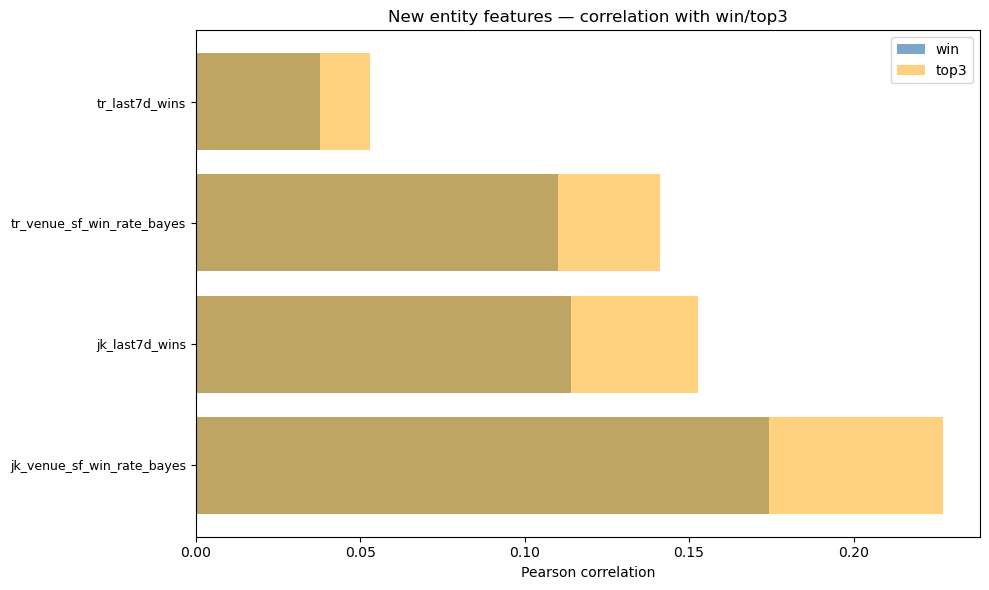

グラフ保存: /home/jovyan/work/keiba-vpn/data/local/modeling/entity_stats/entity_feature_correlation.png


In [9]:
import matplotlib.pyplot as plt

# master dataset から目的変数を取得
if spine is not None:
    master_full = pd.read_parquet(MODELING_DIR / "master_dataset_full.parquet",
                                   columns=["race_id", "horse_number", "is_winner", "is_top3",
                                             "finish_position", "field_size"])
    corr_df = out_df[["race_id", "horse_number"] + entity_cols].merge(
        master_full, on=["race_id", "horse_number"], how="inner"
    )

    # 新規統計量と is_winner / is_top3 の相関
    new_cols = [c for c in entity_cols if any(
        c.startswith(x) for x in ["sire_", "dam_sire_", "jk_last7d", "tr_last7d",
                                    "jk_venue_sf", "tr_venue_sf"]
    )]
    rate_cols = [c for c in new_cols if "rate" in c or "avg" in c or "wins" in c][:20]

    if rate_cols and "is_winner" in corr_df.columns:
        corr_win  = corr_df[rate_cols + ["is_winner"]].corr()["is_winner"].drop("is_winner")
        corr_top3 = corr_df[rate_cols + ["is_top3"]].corr()["is_top3"].drop("is_top3")

        corr_summary = pd.DataFrame({
            "corr_with_win":  corr_win,
            "corr_with_top3": corr_top3,
        }).dropna().sort_values("corr_with_win", key=abs, ascending=False)

        print("=== 新規特徴量と目的変数の相関 (|corr| 降順) ===")
        print(corr_summary.to_string())

        # 棒グラフ
        fig, ax = plt.subplots(figsize=(10, 6))
        idx = corr_summary.index[:15]
        x = range(len(idx))
        ax.barh(list(x), corr_summary.loc[idx, "corr_with_win"],  label="win",  alpha=0.7, color="steelblue")
        ax.barh(list(x), corr_summary.loc[idx, "corr_with_top3"], label="top3", alpha=0.5, color="orange")
        ax.set_yticks(list(x))
        ax.set_yticklabels(list(idx), fontsize=9)
        ax.set_xlabel("Pearson correlation")
        ax.set_title("New entity features — correlation with win/top3")
        ax.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "entity_feature_correlation.png", dpi=100)
        plt.show()
        print(f"グラフ保存: {OUTPUT_DIR}/entity_feature_correlation.png")
else:
    print("WARN: spine がないため相関確認をスキップ")

## 8. NB-01 master dataset への結合 (join パッチ)

NB-01 の master dataset は `entity_stats` が結合されていない状態で保存されている。
ここでエンティティ統計を結合した「拡張版 master dataset」を生成する。

```
data/local/modeling/
├── master_dataset_full_v2.parquet      # entity_stats 結合済み
├── turf/turf_train_v2.parquet          # surface × split 別
├── ...
```

In [10]:
SURFACE_CATS = ["turf", "dirt", "hurdle"]

# entity_stats を結合するヘルパ
def join_entity_stats(master_df: pd.DataFrame, ent_df: pd.DataFrame) -> pd.DataFrame:
    """master_df に entity_stats を left join する。"""
    ent_join_cols = ["race_id", "horse_number"]
    ent_feat_cols = [c for c in ent_df.columns
                     if c.startswith(("jk_", "tr_", "sire_", "dam_sire_"))]
    return master_df.merge(
        ent_df[ent_join_cols + ent_feat_cols],
        on=ent_join_cols, how="left",
    )

# ── 全体 full ──────────────────────────────────────────────────────────────
if (MODELING_DIR / "master_dataset_full.parquet").exists():
    master_full = pd.read_parquet(MODELING_DIR / "master_dataset_full.parquet")
    master_v2 = join_entity_stats(master_full, out_df.drop(columns=["split","horse_id"], errors="ignore"))

    p = MODELING_DIR / "master_dataset_full_v2.parquet"
    master_v2.to_parquet(p, index=False)
    print(f"保存: {p}  shape={master_v2.shape}")

    # ── surface × split の 9 ファイル ─────────────────────────────────────
    for sc in SURFACE_CATS:
        sc_dir = MODELING_DIR / sc
        sc_dir.mkdir(exist_ok=True)
        for sp in SPLITS:
            src = sc_dir / f"{sc}_{sp}.parquet"
            if not src.exists():
                continue
            df_sp = pd.read_parquet(src)
            df_sp_v2 = join_entity_stats(
                df_sp,
                out_df[out_df["split"] == sp].drop(columns=["split","horse_id"], errors="ignore"),
            )
            dst = sc_dir / f"{sc}_{sp}_v2.parquet"
            df_sp_v2.to_parquet(dst, index=False)
            print(f"保存: {sc}/{sc}_{sp}_v2.parquet  shape={df_sp_v2.shape}")

    print("\n完了: _v2 ファイルをモデリングに使用してください")
else:
    print("WARN: master_dataset_full.parquet が見つかりません。NB-01 を先に実行してください。")

保存: /home/jovyan/work/keiba-vpn/data/local/modeling/master_dataset_full_v2.parquet  shape=(286060, 400)


保存: turf/turf_train_v2.parquet  shape=(94265, 400)


保存: turf/turf_valid_v2.parquet  shape=(19935, 400)


保存: turf/turf_test_v2.parquet  shape=(20190, 400)


保存: dirt/dirt_train_v2.parquet  shape=(100016, 400)


保存: dirt/dirt_valid_v2.parquet  shape=(21284, 400)


保存: dirt/dirt_test_v2.parquet  shape=(21655, 400)


保存: hurdle/hurdle_train_v2.parquet  shape=(6153, 400)


保存: hurdle/hurdle_valid_v2.parquet  shape=(1253, 400)


保存: hurdle/hurdle_test_v2.parquet  shape=(1309, 400)

完了: _v2 ファイルをモデリングに使用してください


## 9. 本番推論用スナップショットの生成方法

本番で当日レースを予測する際、以下の手順でエンティティ統計のスナップショットを生成する。

```python
from src.pipeline.features.stallion_target_encoder import (
    build_all_sire_stats,
    build_jt_extended_stats,
)

# 予測対象レースより前の全レース結果を渡す
# cutoff_race_id は "202507100501" のような race_id (YYYYMMDDVVRR)
sire_snap = build_all_sire_stats(
    race_result_all_df,   # 予測日以前のデータ
    cutoff_race_id="202507100501",  # オプション: これ未満の race_id のみ使用
)
jt_ext_snap = build_jt_extended_stats(race_result_all_df)

# 出馬表の各馬に対してマージ
shutuba_with_stats = shutuba_df.merge(sire_snap, on=["race_id", "horse_number"], how="left")
shutuba_with_stats = shutuba_with_stats.merge(jt_ext_snap, on=["race_id", "horse_number"], how="left")
```

### 自動化スケジュール
- 毎朝 6:00: `scripts/cron/update_entity_stats_snapshot.sh` を実行
  → `data/local/features/entity_stats_snapshot.parquet` を更新
- 推論 API は起動時にこのスナップショットをロード（常時ファイルアクセス不要）

詳細は `docs/decisions/AREA-08-entity-stats.md` を参照。